<a href="https://colab.research.google.com/github/manyasiingh/Pytorch_Text_Classification/blob/main/Pytorch_Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
print("GPU Available :", torch.cuda.is_available())
print("GPU Available", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

GPU Available : True
GPU Available Tesla T4


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

In [4]:
from datasets import load_dataset
from transformers import AutoTokenizer
dataset = load_dataset("ag_news")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [4]:
from huggingface_hub import notebook_login
notebook_login()

In [5]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
def tokenize_function(examples):
  return tokenizer(examples["text"], padding = "max_length", truncation=True, max_length = 128)
tokenized_datasets = dataset.map(tokenize_function , batched = True)

#formating dataset for Pytorch

tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [6]:
from torch.utils.data import DataLoader
#Create DataLoaders

train_dataloader =DataLoader(tokenized_datasets["train"] , shuffle = True , batch_size = 23)
test_dataloader =DataLoader(tokenized_datasets["test"] ,batch_size = 23)

In [7]:
from IPython.terminal.embed import embed
import torch.nn as nn
class TextClassifier(nn.Module):
  def __init__(self, vocab_size , embed_dim , num_classes):
    super(TextClassifier, self).__init__()
    self.embedding = nn.Embedding(vocab_size , embed_dim)
    self.fc1 = nn.Linear(embed_dim , 128) #first hidden layer
    self.relu = nn.ReLU() # Activation Function
    self.fc2 = nn.Linear(128, num_classes) # Output layer
  def forward(self, input_ids):
    embedded  =self.embedding(input_ids).mean(dim= 1)
    x = self.fc1(embedded)
    x = self.relu(x)
    output = self.fc2(x)
    return output
vocab_size = tokenizer.vocab_size
embed_dim = 128
num_classes =4
model = TextClassifier(vocab_size , embed_dim , num_classes)


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters() , lr = 5e-4)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

num_epochs= 3
for epoch in range(num_epochs):
  model.train()
  total_loss = 0
  for batch in train_dataloader:
    input_ids = batch["input_ids"].to(device)
    labels = batch["labels"].to(device)
    outputs = model(input_ids)
    loss = criterion(outputs , labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
print(f"Epoch {epoch + 1} , Loss :{total_loss/len(train_dataloader)}")



Epoch 3 , Loss :0.24491070000966672


In [10]:
model.eval()
correct  = 0
total = 0
with torch.no_grad():
  for batch in test_dataloader:
    input_ids = batch["input_ids"].to(device)
    labels = batch["labels"].to(device)
    outputs = model(input_ids)
    predictions = torch.argmax(outputs, dim=1)
    correct += (predictions == labels).sum().item()
    total += labels.size(0)
accuracy = correct / total
print(f"Test Accuracy : {accuracy:.4f}")

Test Accuracy : 0.9074


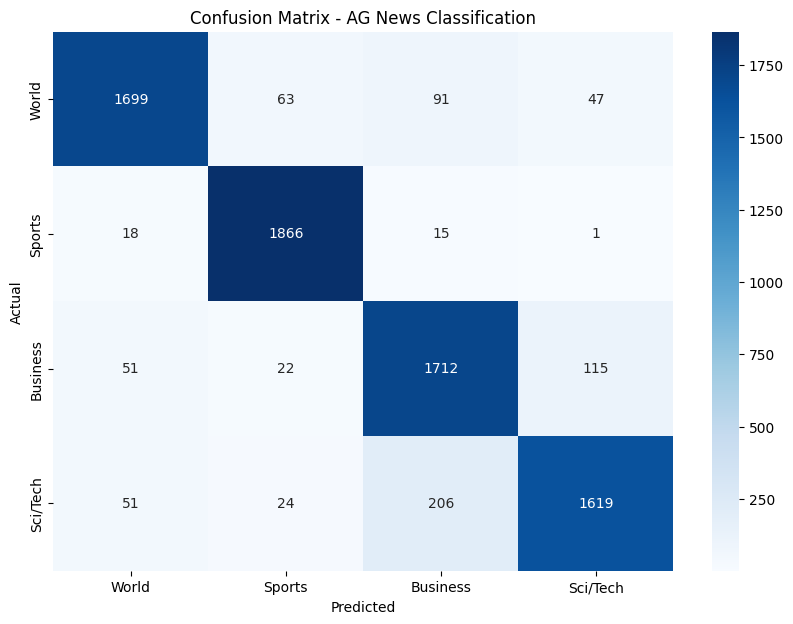

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    categories = ["World", "Sports", "Business", "Sci/Tech"]

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids)
            predictions = torch.argmax(outputs, dim=1)

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=categories, yticklabels=categories, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - AG News Classification')
    plt.savefig('confusion_matrix.png') # This saves the image for your GitHub!
    plt.show()

plot_confusion_matrix(model, test_dataloader, device)

In [12]:
def classify_text(text):
  model.eval()
  inputs = tokenizer(text , return_tensors = "pt", padding = "max_length" , truncation=True , max_length=128).to(device)
  with torch.no_grad():
    outputs  =model(inputs["input_ids"])
  prediction = torch.argmax(outputs, dim=1).item()
  categories = ["World", "Sports", "Business", "Sci/Tech"]
  return categories[prediction]



In [17]:
text = "Donald Trump"
print(f"Predicted Category: {classify_text(text)}")

Predicted Category: Business
